In [26]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain.messages import RemoveMessage
import os

In [27]:
load_dotenv()

True

In [28]:
model = ChatGroq(
    model="openai/gpt-oss-120b",
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0
)

In [29]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [30]:


builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)



In [31]:


builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")



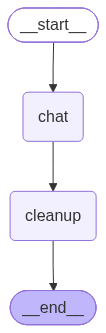

In [32]:
graph = builder.compile(checkpointer=InMemorySaver())
graph


In [33]:
config = {"configurable": {"thread_id": "t1"}}

In [34]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Sangram"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "what LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "what checkpointers"}]}, config)



{'messages': [HumanMessage(content="Hi, I'm Sangram", additional_kwargs={}, response_metadata={}, id='f57a67c9-190c-492c-a10c-6c180d20c36b'),
  AIMessage(content='Hello Sangram! 👋 Nice to meet you. How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says "Hi, I\'m Sangram". Likely they want a greeting. We should respond politely, maybe ask how can help. No disallowed content. So respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 76, 'total_tokens': 141, 'completion_time': 0.140028289, 'completion_tokens_details': {'reasoning_tokens': 38}, 'prompt_time': 0.003101709, 'prompt_tokens_details': None, 'queue_time': 0.400502603, 'total_time': 0.143129998}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e1a78f200e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0ca87-3d32-77d1-b8b6-c73c96cfc659-0', tool_calls=[], invalid_tool_calls=[], 

In [36]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))


Stored messages after cleanup: 6
